# **RFscorer チュートリアル 実践編 (日本語)**

このノートブックでは `rfscorer` の実践的な利用方法を説明します。

具体的には次のワークフローを通じて学びます。

1. データを時系列で**訓練データ・テストデータ分割**
2. **観測データ・正解データ**を作成して `fit()` でモデルを構築
3. 全 **9 種のモデル** で推薦スコアを計算して精度を比較
4. モデルを **pickle** で保存・ロード

なお、Google Colab で利用する場合、次の準備が必要になります。
- `rfscorer`のインストール
```python
!pip install rfscorer
```
- Googleドライブのマウント（ファイルの入出力をする場合）
```python
from google.colab import drive
drive.mount("/content/drive")
```

---
## **データ取得と前処理**
GitHub上の公開データセットをURL経由でデータフレームとして直接読み込み、次の2段階でデータを分割します。

- **時系列分割**: 基準日で区切り、過去を訓練・直近を評価に使う（運用＝過去データで未来を予測する状況を再現）
- **期間分割**: 各データを観測データと正解データに分ける

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

In [2]:
# `access_log.csv` は ohmsha/PyOptBook (MIT License)
# https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
# RecencyFrequencyScorer のデフォルト列名（user_col="user", item_col="item", time_col="datetime"）に合わせてリネーム
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
print("datetime num:", len(sorted(df.datetime.unique())))
print("datetime:", sorted(df.datetime.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611
datetime num: 8
datetime: ['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08']


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


In [3]:
# 時系列で訓練データ・テストデータに分割（運用を想定: 過去データで未来を予測する）
# df_train: 学習時点で利用可能なデータ（2015-07-07 まで）
# df_test : 評価用（予測対象日 2015-07-08）
target_date = "2015-07-07"
gt_date = "2015-07-08"
df_train = df[df.datetime <= target_date]
df_test = df[df.datetime <= gt_date]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 285975 / user num: 28605
test  record num:  325908 / user num:  31443


In [4]:
# split_by_date() で訓練・テストデータをそれぞれ観測データと正解データに分割
# 観測データ（基準日以前の 6 日間）: 最新度・頻度を算出する期間のデータ
# 正解データ（基準日翌日の 1 日間）: 対象イベント（再閲覧・購買・CVなど）の発生を記録するデータ
# 訓練は fit_date（正解=翌日 07-07）、評価は target_date（正解=翌日 07-08）を基準に揃える
fit_date = "2015-07-06"  # 学習の基準日
df_train_obs, df_train_gt = split_by_date(df_train, fit_date, observation_days=6, gt_days=1)
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=6, gt_days=1)

print("--- train ---")
print("obs/datetime num:", len(sorted(df_train_obs.datetime.unique())))
print(sorted(df_train_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_train_gt.datetime.unique())))
print(sorted(df_train_gt.datetime.unique()))

print("--- test ---")
print("obs/datetime num:", len(sorted(df_test_obs.datetime.unique())))
print(sorted(df_test_obs.datetime.unique()))
print("gt/datetime num:", len(sorted(df_test_gt.datetime.unique())))
print(sorted(df_test_gt.datetime.unique()))

--- train ---
obs/datetime num: 6
['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06']
gt/datetime num: 1
['2015-07-07']
--- test ---
obs/datetime num: 6
['2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07']
gt/datetime num: 1
['2015-07-08']


---
## **モデル構築と可視化**

訓練データを使って経験的商品選択確率を推定し（`fit`）、6 種の最適化モデルを構築します。

| モデル | 種別 | 制約 |
|--------|------|------|
| `emp` | 経験的（2D） | なし |
| `er` / `ef` | 経験的（1D） | なし |
| `mr` | 最適化（1D） | Recency 単調性 + 凸性 |
| `mf` | 最適化（1D） | Frequency 単調性 + 凹性 |
| `mono` | 最適化（2D） | 単調性のみ |
| `mrc` | 最適化（2D） | 単調性 + Recency 凸性 |
| `mfc` | 最適化（2D） | 単調性 + Frequency 凹性 |
| `mcc` | 最適化（2D） | 単調性 + Recency 凸性 + Frequency 凹性 |

In [5]:
# デフォルト列名（user_col="user", item_col="item", time_col="datetime"）を使用するため引数なし
scorer = RecencyFrequencyScorer()

In [6]:
# === fit ===
# fit_date    : 2015-07-06
# target_date : 2015-07-07
# gt_date     : 2015-07-08
#                    f t g
#                    ^ ^ ^
# 2015-07-01 2 3 4 5 6 7 8
# test       * * * * * * @
# train    * * * * * * @
# *: 観測（observation_days=6）,  @: 正解（gt_days=1）
scorer.fit(df_train_obs, df_train_gt, ref=fit_date, recency_limit=6, frequency_limit=15)

scorer.show()  # データ統計・相関係数・経験的商品選択確率テーブルを表示

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_mode     : day
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expe

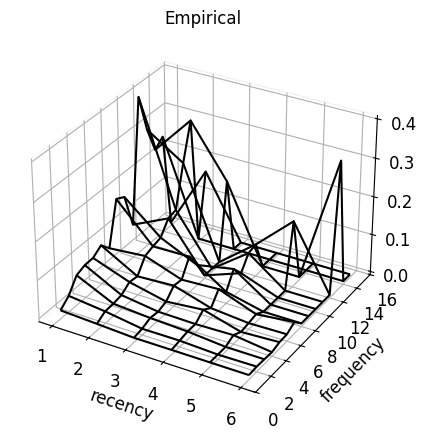

In [7]:
# 経験的商品選択確率（emp）の3次元可視化
# 観測データから直接算出した生の商品選択確率: 標本ノイズを含み単調性を満たさないセルがある
fig_emp = scorer.plot_probability_surface(kind="emp")
fig_emp.savefig("surface_empirical_probability.png")

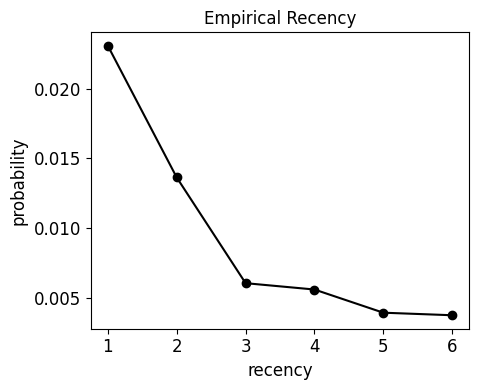

In [8]:
# 最新度の1次元経験的商品選択確率（er）
# 期待される傾向: recency が小さい（より直近で閲覧）ほど確率が高い（負の傾き）
fig_er = scorer.plot_marginal_probability(kind="er")
fig_er.savefig("marginal_empirical_recency_probability.png")

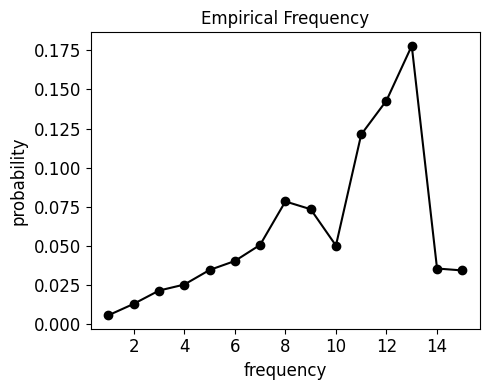

In [9]:
# 頻度の1次元経験的商品選択確率（ef）
# 期待される傾向: frequency が高い（閲覧頻度が多い）ほど確率が高い（正の傾き）
fig_ef = scorer.plot_marginal_probability(kind="ef")
fig_ef.savefig("marginal_empirical_frequency_probability.png")

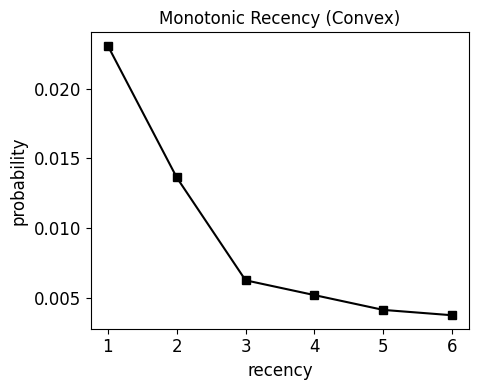

In [10]:
# mr: 1次元 Recency 最適化モデル（単調減少 + 凸性制約）
# 凸性 = 直近ほど確率の落ち幅が大きい
scorer.optimize(kind="mr")
fig_mr = scorer.plot_marginal_probability(kind="mr")
fig_mr.savefig("marginal_monotonic_recency_probability.png")

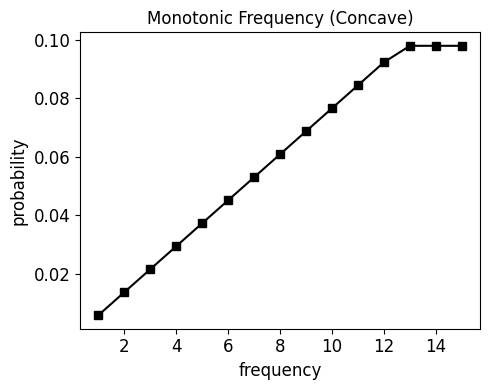

In [11]:
# mf: 1次元 Frequency 最適化モデル（単調増加 + 凹性制約）
# 凹性 = 頻度が増えるほど確率の上昇幅が小さくなる
scorer.optimize(kind="mf")
fig_mf = scorer.plot_marginal_probability(kind="mf")
fig_mf.savefig("marginal_monotonic_frequency_probability.png")

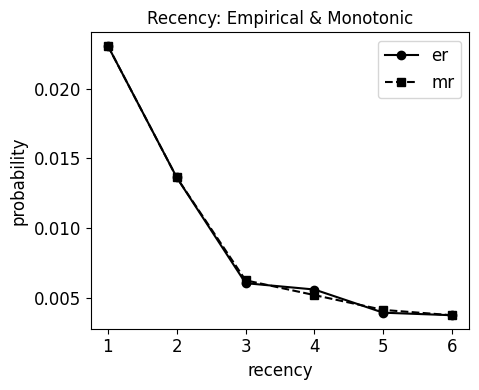

In [12]:
# 経験的（er）と最適化（mr）の Recency 確率を重ねて比較
# 最適化によりノイズが除去され、単調凸な滑らかな曲線であることを確認
fig_rboth = scorer.plot_marginal_probability(kind="rboth")
fig_rboth.savefig("marginal_recencys_probability.png")

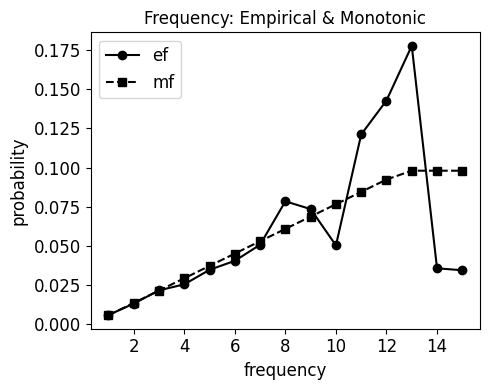

In [13]:
# 経験的（ef）と最適化（mf）の Frequency 確率を重ねて比較
# 最適化によりノイズが除去され、単調凹な滑らかな曲線であることを確認
fig_fboth = scorer.plot_marginal_probability(kind="fboth")
fig_fboth.savefig("marginal_frequencys_probability.png")

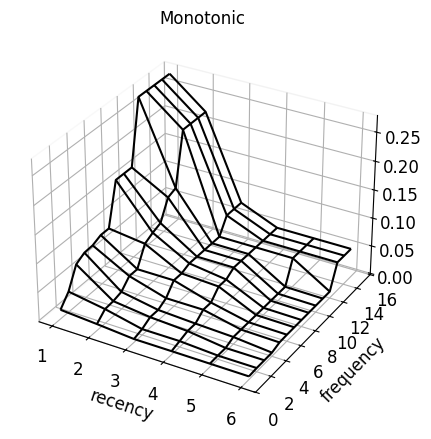

In [14]:
# mono: 2次元単調性モデル（Recency 単調減少 + Frequency 単調増加）
# 凹凸性制約は課さない最もシンプルな2次元最適化モデル
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")
fig_mono.savefig("surface_monotonic_probability.png")

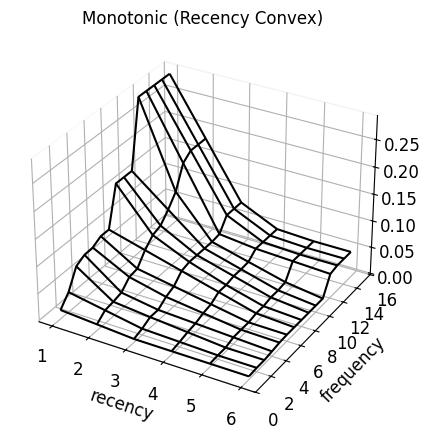

In [15]:
# mrc: 単調性 + Recency 凸性制約
# 凸性 = 直近になるほど確率の落ち幅が大きい（Recency 軸の曲面が上に凸）
scorer.optimize(kind="mrc")
fig_mrc = scorer.plot_probability_surface(kind="mrc")
fig_mrc.savefig("surface_monotonic_recency_convex_probability.png")

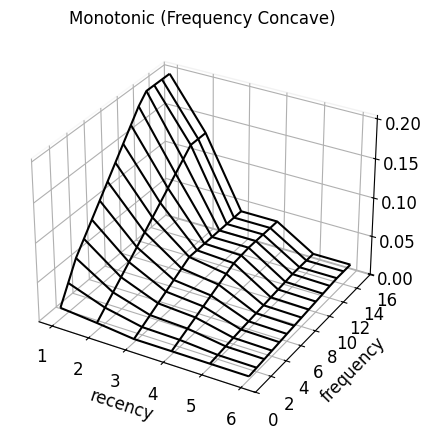

In [16]:
# mfc: 単調性 + Frequency 凹性制約
# 凹性 = 頻度が増えるほど確率の上昇幅が小さくなる（Frequency 軸の曲面が下に凸）
scorer.optimize(kind="mfc")
fig_mfc = scorer.plot_probability_surface(kind="mfc")
fig_mfc.savefig("surface_monotonic_frequency_concave_probability.png")

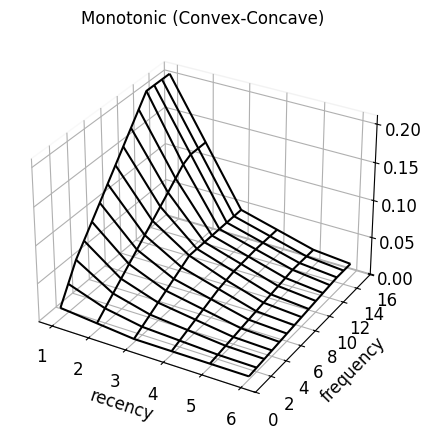

In [17]:
# mcc: 単調性 + Recency 凸性 + Frequency 凹性（制約が最も強いモデル）
# 両方向の凹凸性を同時に課すことで、最も滑らかな曲面が得られる
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")
fig_mcc.savefig("surface_monotonic_convex_concave_probability.png")

In [18]:
# kind="all": emp/er/ef/mono/mr/mf/mrc/mfc/mcc の全モデルを1ファイルにまとめて出力
scorer.export_probability_csv(kind="all")

# 個別モデルごとに CSV を出力（モデルを単独で参照したい場合）
kinds = ["er", "ef", "mr", "mf", "emp", "mono", "mrc", "mfc", "mcc"]
for kind in kinds:
    fname = f"prob_{kind}.csv"
    scorer.export_probability_csv(kind=kind, path=fname)

---
## **推薦結果の取得と評価**

テストデータの観測データ（`df_test_obs`）に全モデルの確率を付与し（`transform`）、  
正解データ（`df_test_gt`）と照合して推薦精度を評価します（`evaluate`）。

In [19]:
# テストデータの観測データ df_test_obs に各モデルが予測する商品選択確率と推薦順位を付与
# ref=target_date: 評価時点（運用時の「今日」）を基準に最新度を計算
kind2df_rec = {kind: scorer.transform(df_test_obs, target_date, kind=kind) for kind in kinds}

In [20]:
# 推薦結果の表示
for kind in kinds:
    print("---", kind, "---")
    display(kind2df_rec[kind].head(3))

--- er ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003734,1
72,100,185046,6,1,0.003734,2
73,100,1002465,6,1,0.003734,3


--- ef ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.005897,1
72,100,185046,6,1,0.005897,2
73,100,1002465,6,1,0.005897,3


--- mr ---


...

,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003436,1
72,100,185046,6,1,0.003436,2
73,100,1002465,6,1,0.003436,3


--- mfc ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003413,1
72,100,185046,6,1,0.003413,2
73,100,1002465,6,1,0.003413,3


--- mcc ---


,user,item,recency,frequency,probability,order
71,100,311746,6,1,0.003398,1
72,100,185046,6,1,0.003398,2
73,100,1002465,6,1,0.003398,3


In [21]:
# 推薦結果の評価（order=3: 推薦順位 1〜3 位でのカットオフ評価）
# precision / recall / f1 に加え、到達可能な最大ヒット数で正規化した recall_norm / f1_norm も出力
# 最終行は全推薦件数での上限値（recall_norm=1.0 になる点）
for kind, df_rec in kind2df_rec.items():
    print("---", kind, "---")
    display(scorer.evaluate(df_rec, df_test_gt, order=3))

--- er ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,418,0.016470,0.014097,0.015191,0.210579,0.030550
1,2,48391,680,0.014052,0.022933,0.017427,0.342569,0.026997
2,3,65355,860,0.013159,0.029004,0.018104,0.433249,0.025542
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- ef ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,505,0.019898,0.017031,0.018353,0.254408,0.036908
1,2,48391,824,0.017028,0.027790,0.021117,0.415113,0.032714
2,3,65355,991,0.015163,0.033422,0.020862,0.499244,0.029433
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mr ---


...

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,541,0.021316,0.018246,0.019662,0.272544,0.039540
1,2,48391,840,0.017359,0.028330,0.021527,0.423174,0.033349
2,3,65355,1027,0.015714,0.034636,0.021620,0.517380,0.030502
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mfc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,543,0.021395,0.018313,0.019734,0.273552,0.039686
1,2,48391,843,0.017421,0.028431,0.021604,0.424685,0.033468
2,3,65355,1028,0.015729,0.034670,0.021641,0.517884,0.030532
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


--- mcc ---


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,25380,545,0.021474,0.018380,0.019807,0.274559,0.039832
1,2,48391,844,0.017441,0.028464,0.021629,0.425189,0.033508
2,3,65355,1029,0.015745,0.034704,0.021662,0.518388,0.030561
3,288,173703,1985,0.011428,0.066945,0.019523,1.000000,0.022597


In [22]:
# 全モデルの precision@1 を集計して比較
# 最適化モデル（mcc > mfc > mono > mrc）が経験的モデル（emp）を上回る傾向がみられる
Rows = []
for kind, df_rec in kind2df_rec.items():
    top = scorer.evaluate(df_rec, df_test_gt, order=1).iloc[0]
    precision = top["precision"]
    recall = top["recall"]
    f1 = top["f1"]
    Rows.append((kind, precision, recall, f1))
df_eval = pd.DataFrame(Rows, columns=["kind", "precision", "recall", "f1"])
df_eval.sort_values("precision", ascending=False)

,kind,precision,recall,f1
8,mcc,0.021474,0.018380,0.019807
7,mfc,0.021395,0.018313,0.019734
5,mono,0.021355,0.018279,0.019698
6,mrc,0.021316,0.018246,0.019662
4,emp,0.020567,0.017605,0.018971
1,ef,0.019898,0.017031,0.018353
3,mf,0.019858,0.016998,0.018317
0,er,0.016470,0.014097,0.015191
2,mr,0.016470,0.014097,0.015191


In [23]:
# precision@1 が最も高かった mcc モデルの推薦結果を CSV に保存
kind2df_rec["mcc"].to_csv("recommendations.csv", index=False)

In [24]:
# モデルの保存
scorer.save("rfscorer.pkl")

In [25]:
# モデルのロード
scorer_loaded = RecencyFrequencyScorer.load("rfscorer.pkl")
scorer_loaded.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_mode     : day
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expe

---
## **その他の機能**

列名のカスタマイズ、グラフの詳細設定、個別商品選択確率の取得、zip アーカイブ保存など補足的な使い方を紹介します。

In [26]:
# 実際のデータでは列名が user/item/datetime 以外のことが多い
# コンストラクタの user_col / item_col / time_col でカラム名を指定する
df_renamed = df.rename(columns={"user": "customer_id", "item": "product_id", "datetime": "date"})
df_train_r = df_renamed[df_renamed.date <= "2015-07-07"]
df_test_r = df_renamed[df_renamed.date <= "2015-07-08"]

scorer_r = RecencyFrequencyScorer(user_col="customer_id", item_col="product_id", time_col="date")
df_obs_r, df_gt_r = split_by_date(
    df_train_r, fit_date, observation_days=6, gt_days=1, time_col="date"
)
scorer_r.fit(df_obs_r, df_gt_r, ref=fit_date, recency_limit=6, frequency_limit=15)

df_test_obs_r, _ = split_by_date(
    df_test_r, target_date, observation_days=6, gt_days=1, time_col="date"
)
scorer_r.optimize(kind="mcc")
scorer_r.transform(df_test_obs_r, target_date, kind="mcc").head()

,customer_id,product_id,recency,frequency,probability,order
71,100,311746,6,1,0.003398,1
72,100,185046,6,1,0.003398,2
73,100,1002465,6,1,0.003398,3
40705,100003,675829,4,1,0.003634,1
40706,100003,979166,4,1,0.003634,2


In [27]:
# predict(r, f): 特定の (最新度, 頻度) ペアに対する商品選択確率を1件取得
# 1日前に1回閲覧した商品の選択確率と 2日前に2回閲覧した商品の選択確率の比較
for kind in kinds:
    print(
        f"  {kind:4s}: {scorer.predict(1, 1, kind=kind):.6f} v.s. {scorer.predict(2, 2, kind=kind):.6f}"
    )

  er  : 0.023089 v.s. 0.013630
  ef  : 0.005897 v.s. 0.013178
  mr  : 0.023089 v.s. 0.013630
  mf  : 0.005751 v.s. 0.013628
  emp : 0.013819 v.s. 0.022967
  mono: 0.013819 v.s. 0.022967
  mrc : 0.013950 v.s. 0.021801
  mfc : 0.013554 v.s. 0.019616
  mcc : 0.013788 v.s. 0.019243


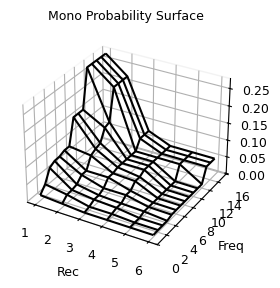

In [28]:
# figsize・fontsize・各軸ラベルを調整することで論文・レポート向けのグラフを作成できる
fig_mono = scorer.plot_probability_surface(
    kind="mono",
    title="Mono Probability Surface",
    figsize=(4, 3),
    fontsize=9,
    recency_label="Rec",
    frequency_label="Freq",
    probability_label="Prob",
)

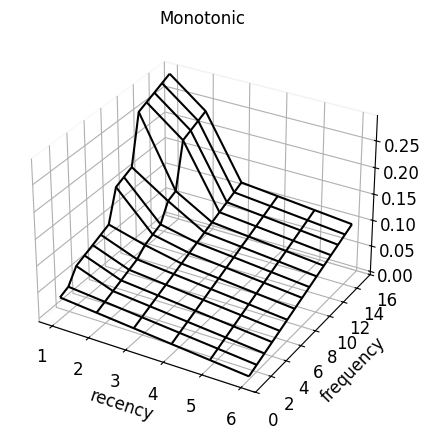

In [29]:
# epsを設定して、狭義単調増加・狭義単調減少のモデルを推定する(以下ではわかりやすさのため eps に大きな値を設定)
scorer.optimize(kind="mono", eps=0.007)
fig_mcc = scorer.plot_probability_surface(kind="mono")

In [30]:
# 最適化計算の情報を表示する
scorer.optimize(kind="mcc", verbose=True)

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 4.4598
elapsed_time: 0.12[s]
num_variables: 90
num_constraints: 477


In [31]:
# save_zip(): pickle + metadata.json + 確率テーブル CSV + プロット PNG を zip にまとめて保存
# 研究者間の共有・成果物管理（確率テーブルをアーカイブと一緒に保存）に便利
scorer.save_zip("scorer.zip")

# load_zip(): zip からモデルを復元（CSV/PNG は zip 内に保存されているが Python 側には読み込まれない）
scorer_loaded_zip = RecencyFrequencyScorer.load_zip("scorer.zip")
scorer_loaded_zip.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 252045 rows,  gt 33930 events  (users: 26030,  items: 74811)
  observation      : 2015-07-01 → 2015-07-06
  user×item pairs  : 180840 → 180752  (before → after applying limits)
  target events    : 1597 → 1585  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_mode     : day
  recency_limit    : 6
  frequency_limit  : 15

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=6,  weighted ρ: -1.0000)
  frequency ρ      :  0.6500  (p=0.0087,  n=15,  weighted ρ:  0.9713)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9280
    r= 2:   0.9854
    r= 3:   0.7712
    r= 4:   0.9303
    r= 5:   0.6182
    r= 6:   0.4109
  Slice ρ by f  [corr(r, P(r,f)),  expe